# NumPy Project 1 — Array Operations and Signal Statistics

## What this project does
Practises core NumPy array operations on real signals.
Computes statistical properties that RF engineers use every day.

## NumPy concepts covered
- Array creation, slicing, reshaping
- Mathematical operations on arrays
- Statistical functions: mean, std, min, max, percentile
- Boolean indexing

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- different ways to create arrays ---
a = np.array([1, 2, 3, 4, 5])
# np.array(): creates an array from a Python list
# result: [1 2 3 4 5]

b = np.zeros(5)
# np.zeros(n): creates array of n zeros
# result: [0. 0. 0. 0. 0.]

c = np.ones(5)
# np.ones(n): creates array of n ones

d = np.linspace(0, 1, 5)
# np.linspace(start, stop, num): creates num evenly spaced values between start and stop
# INCLUSIVE of both endpoints — different from np.arange which excludes stop
# result: [0.   0.25 0.5  0.75 1.  ]

e = np.arange(0, 1, 0.2)
# np.arange(start, stop, step): values from start to stop, stepping by step
# EXCLUDES stop — result: [0 2 4 6 8]

print("np.array:", a)
print("np.zeros:", b)
print("np.ones:", c)
print("np.linspace:", d)
print("np.arange:", e)

np.array: [1 2 3 4 5]
np.zeros: [0. 0. 0. 0. 0.]
np.ones: [1. 1. 1. 1. 1.]
np.linspace: [0.   0.25 0.5  0.75 1.  ]
np.arange: [0.  0.2 0.4 0.6 0.8]


In [4]:
fs = 1000
T = 1

t = np.arange(0, 1, 1/fs)
signal = np.sin(2 * np.pi * 50 * t)
# 50 Hz sine wave — our test signal

# --- slicing ---
first_100 = signal[:100]
# signal[:100]: elements from index 0 to 99 — first 100 samples

last_100 = signal[-100:]
# signal[-100:]: last 100 samples — negative index counts from end

middle = signal[400:600]
# signal[400:600]: samples from index 400 to 599

every_other = signal[::2]
# signal[::2]: every 2nd sample — step of 2
# this is downsampling by factor 2 — halves the sampling rate

print(f"Full signal length:    {len(signal)}")
print(f"First 100 samples:     {len(first_100)}")
print(f"Last 100 samples:      {len(last_100)}")
print(f"Middle 200 samples:    {len(middle)}")
print(f"Every other sample:    {len(every_other)}")
print(f"\nFirst 5 values:  {signal[:5].round(4)}")
print(f"Last 5 values:   {signal[-5:].round(4)}")
# .round(4): rounds to 4 decimal places for clean printing

Full signal length:    1000
First 100 samples:     100
Last 100 samples:      100
Middle 200 samples:    200
Every other sample:    500

First 5 values:  [0.     0.309  0.5878 0.809  0.9511]
Last 5 values:   [-1.     -0.9511 -0.809  -0.5878 -0.309 ]


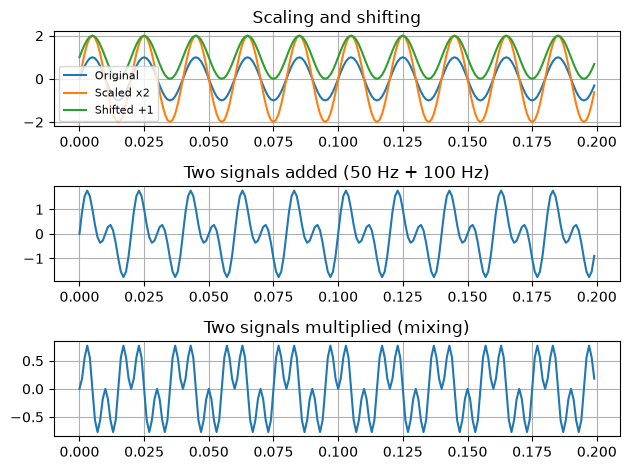

In [6]:
# --- operations apply to every element simultaneously ---
signal_scaled = signal * 2
# multiplies every sample by 2.0 — doubles the amplitude

signal_shifted = signal + 1
# adds 1.0 to every sample — shifts the signal up (DC offset)

signal_squared = signal ** 2
# squares every sample — used for power calculations

signal_abs = np.abs(signal)
# np.abs(): absolute value of every sample — rectification

# --- two array operations ---
signal2 = np.sin(2*np.pi*100*t)
# second sine wave at 100 Hz

mixed = signal + signal2
# adds two arrays element by element — mixing two signals

multiplied = signal * signal2
# multiplies two arrays element by element — signal mixing / modulation

plt.subplot(3, 1, 1)
# plt.subplot(rows, cols, index): creates subplot at position index
# (3, 1, 1): 3 rows, 1 column, first subplot

plt.plot(t[:200], signal[:200], label="Original")
plt.plot(t[:200], signal_scaled[:200], label="Scaled x2")
plt.plot(t[:200], signal_shifted[:200], label="Shifted +1")
plt.legend(fontsize=8)
plt.title("Scaling and shifting")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t[:200], mixed[:200])
plt.title("Two signals added (50 Hz + 100 Hz)")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t[:200], multiplied[:200])
plt.title("Two signals multiplied (mixing)")
plt.grid(True)

plt.tight_layout()
plt.show()



In [27]:
# add noise to make statistics more interesting
noise = np.random.randn(len(signal)) * 0.3

noisy = 2 * signal + noise

# --- key statistical functions ---
mean = np.mean(noisy)
# np.mean(): average of all samples
# for a pure sine wave this should be close to 0 (symmetric around zero)

std_val = np.std(noisy)
# np.std(): standard deviation — measure of spread around the mean
# for a sine wave of amplitude 1: std ≈ 0.707 (1/sqrt(2))

rms_val = np.sqrt(np.mean( noisy ** 2))
# RMS (Root Mean Square) = sqrt(mean of squared samples)
# RMS = std when mean is zero
# RMS is the standard measure of signal power in RF engineering

min_val = np.min(noisy)
max_val = np.max(noisy)
# np.min(), np.max(): smallest and largest sample values

peak_to_peak = max_val - min_val
# peak to peak amplitude — used in oscilloscope measurements

p25 = np.percentile(noisy, 25)
p75 = np.percentile(noisy,75)
# np.percentile(array, q): value below which q% of samples fall
# p25: 25th percentile, p75: 75th percentile

print("=== Signal Statistics ===")
print(f"Mean:          {mean:.4f}  (should be ~0 for sine wave)")
print(f"Std deviation: {std_val:.4f}")
print(f"RMS:           {rms_val:.4f}  (should be ~0.707 for amplitude=1 sine)")
print(f"Min:           {min_val:.4f}")
print(f"Max:           {max_val:.4f}")
print(f"Peak-to-peak:  {peak_to_peak:.4f}")
print(f"25th pctile:   {p25:.4f}")
print(f"75th pctile:   {p75:.4f}")


=== Signal Statistics ===
Mean:          -0.0094  (should be ~0 for sine wave)
Std deviation: 1.4437
RMS:           1.4437  (should be ~0.707 for amplitude=1 sine)
Min:           -2.7380
Max:           2.5598
Peak-to-peak:  5.2978
25th pctile:   -1.3671
75th pctile:   1.3783


Total samples:         1000
Samples above zero:    494
Large amplitude samples (>0.8): 387
Peak sample index:     605
Peak sample time:      0.6050 seconds
Peak sample value:     1.8690


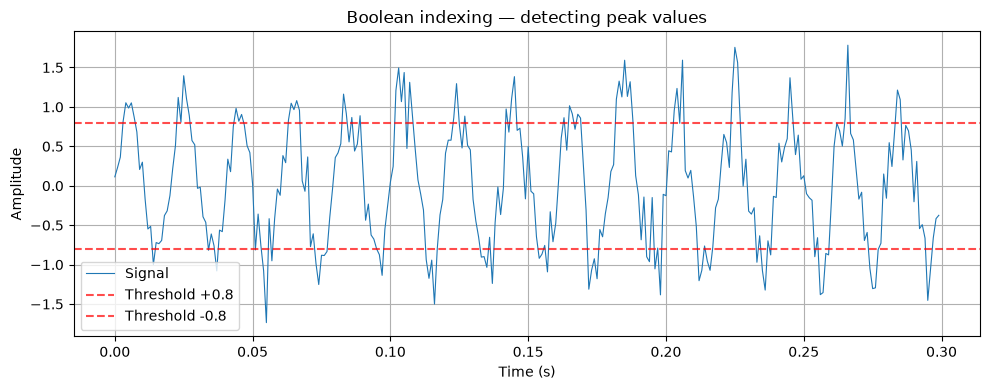

In [24]:
# --- boolean indexing: select samples that meet a condition ---

above_zero = noisy[noisy>0]
# noisy > 0: creates a boolean array (True/False for each sample)
# noisy[...]: selects only samples where condition is True
# result: all positive samples

# new = noisy[(noisy <0.5) & (noisy>-0.5)]
# print(len(new))

large_values = noisy[np.abs(noisy)>0.8]
# np.abs(noisy) > 0.8: True where amplitude exceeds 0.8
# selects samples that are peaks — above 0.8 or below -0.8

# find index of maximum value
max_arg = np.argmax(np.abs(noisy))
# np.argmax(): returns the INDEX of the maximum value
# np.abs(noisy): we want the index of the largest magnitude (positive or negative)

print(f"Total samples:         {len(noisy)}")
print(f"Samples above zero:    {len(above_zero)}")
print(f"Large amplitude samples (>0.8): {len(large_values)}")
print(f"Peak sample index:     {max_arg}")
print(f"Peak sample time:      {t[max_arg]:.4f} seconds")
print(f"Peak sample value:     {noisy[max_arg]:.4f}")

# plot showing detected peaks
plt.figure(figsize=(10, 4))
plt.plot(t[:300], noisy[:300], label="Signal", linewidth=0.8)
plt.axhline(y=0.8,  color='r', linestyle='--', alpha=0.7, label="Threshold +0.8")
plt.axhline(y=-0.8, color='r', linestyle='--', alpha=0.7, label="Threshold -0.8")
# plt.axhline(): draws horizontal line across the plot
# y: the y value where the line sits

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Boolean indexing — detecting peak values")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Original shape:     (100,)
Reshaped to 10x10:  (10, 10)
Signal as frames:   (10, 100)
Frame 0 (first 100 samples): [0.     0.309  0.5878 0.809  0.9511] ...


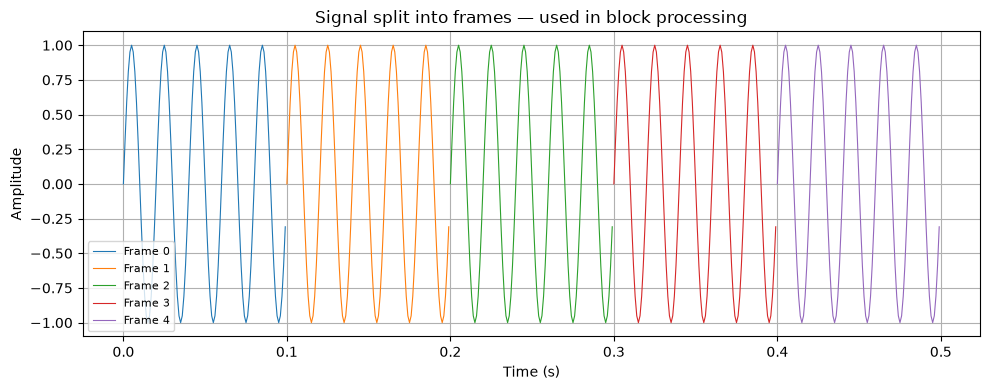

In [25]:
# --- reshaping: changing array dimensions ---
signal_sample = signal[:100]
# take first 100 samples for reshaping demo

reshaped_2d = signal_sample.reshape(10, 10)
# .reshape(rows, cols): converts 1D array of 100 elements into 10x10 matrix
# total elements must stay the same: 10 x 10 = 100

reshaped_frames = signal.reshape(10, 100)
# reshape signal into 10 frames of 100 samples each
# this is how signals are processed in blocks in real systems

print(f"Original shape:     {signal_sample.shape}")
# .shape: tuple showing dimensions of the array

print(f"Reshaped to 10x10:  {reshaped_2d.shape}")
print(f"Signal as frames:   {reshaped_frames.shape}")
print(f"Frame 0 (first 100 samples): {reshaped_frames[0, :5].round(4)} ...")
# reshaped_frames[0, :5]: row 0, first 5 columns

# visualise frames
plt.figure(figsize=(10, 4))
for i in range(5):
    frame_t = np.arange(100) / fs
    plt.plot(frame_t + i * 0.1, reshaped_frames[i],
             label=f"Frame {i}", linewidth=0.8)
    # offset each frame by i * 0.1 seconds so they sit side by side

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Signal split into frames — used in block processing")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()



## Key observations
- Mean and RMS values of noisy signal are 0.0023 and 0.7769 respectively
- Write what boolean indexing returned for large amplitude samples
- Reshaping into frames means the samples are split into blocks of fixed number of samples

## What I learned
- NumPy operations apply to entire arrays at once — no for loops needed
- RMS is the standard power measure in RF engineering
- Boolean indexing is how threshold detection works in real systems
- Reshaping is how signals are split into blocks for processing
- np.linspace vs np.arange: linspace includes endpoint, arange excludes it